In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
sample = pd.read_csv('sample_submission.csv')
train = pd.read_csv('train.csv')
train.drop(columns=['id'], inplace=True)
test = pd.read_csv('test.csv')
train.shape, test.shape, sample.shape

((700000, 25), (300000, 25), (300000, 2))

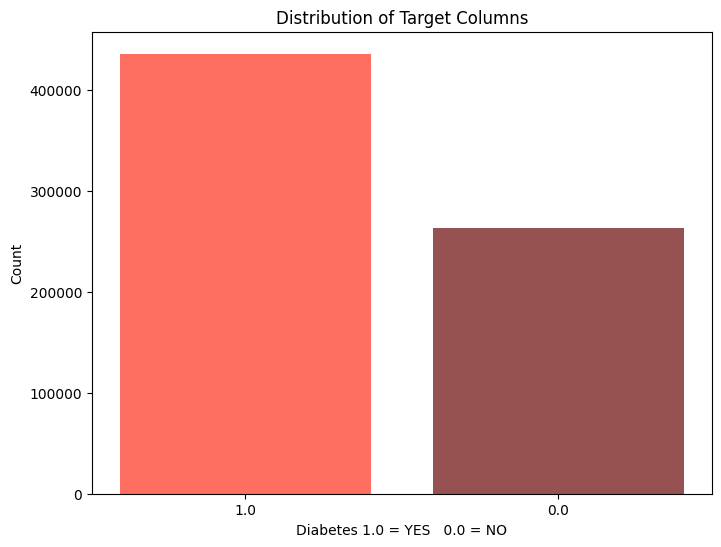

In [3]:
# Target Columns distribution
count = train.diagnosed_diabetes.value_counts()

# Ploting Plot For Target Variable
plt.figure(figsize= (8,6))
plt.bar(count.index.astype(str),count,color = ['#FF6F61','#955251'])
plt.title("Distribution of Target Columns")
plt.xlabel("Diabetes 1.0 = YES   0.0 = NO")
plt.ylabel("Count")
plt.show()

In [14]:
NUMS = ['age','alcohol_consumption_per_week','physical_activity_minutes_per_week','diet_score','sleep_hours_per_day','screen_time_hours_per_day','bmi','waist_to_hip_ratio','systolic_bp','diastolic_bp','heart_rate','cholesterol_total','hdl_cholesterol','ldl_cholesterol','triglycerides','family_history_diabetes','hypertension_history','cardiovascular_history']
CAT = ['gender','ethnicity','education_level','income_level','smoking_status','employment_status']
TARGET = 'diagnosed_diabetes'

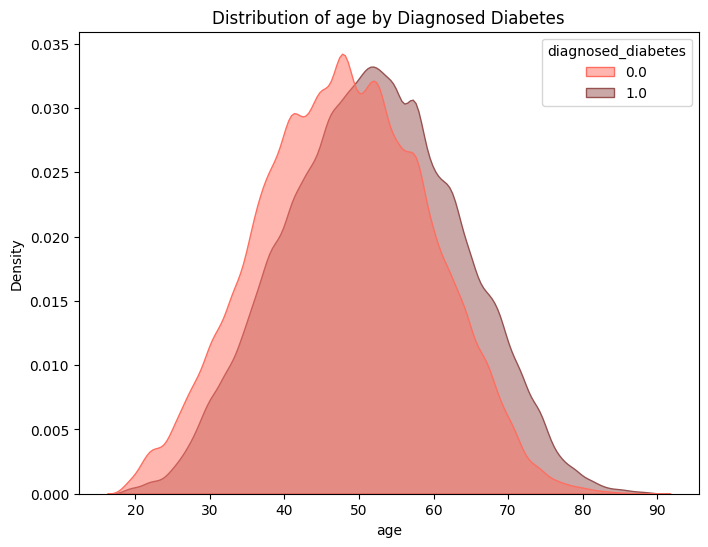

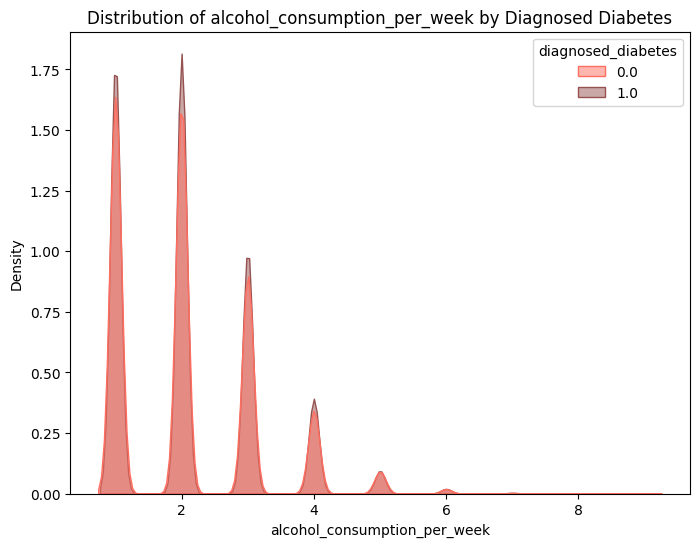

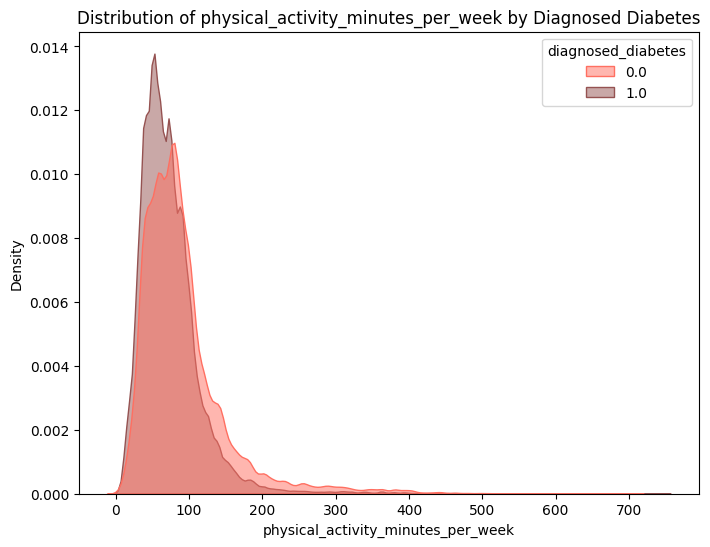

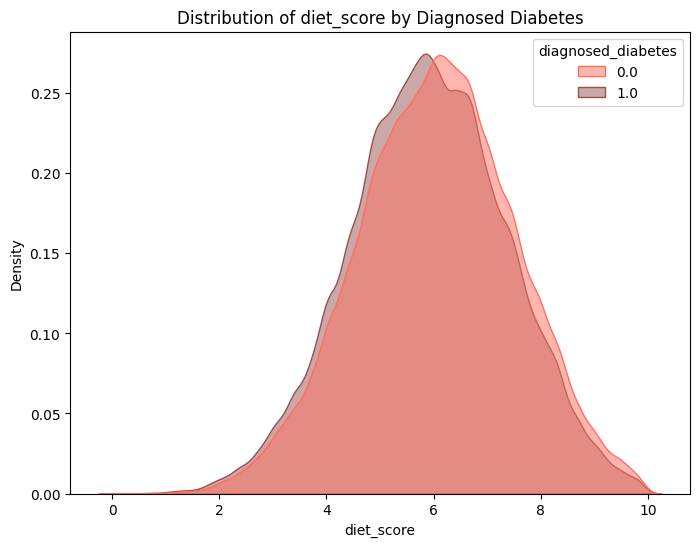

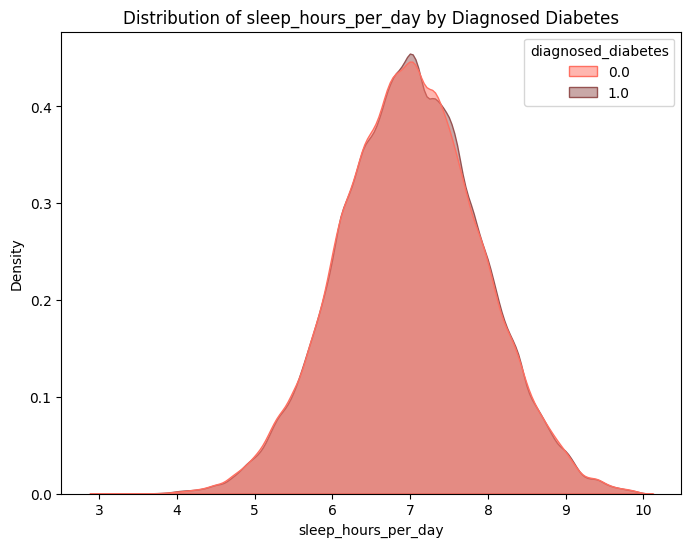

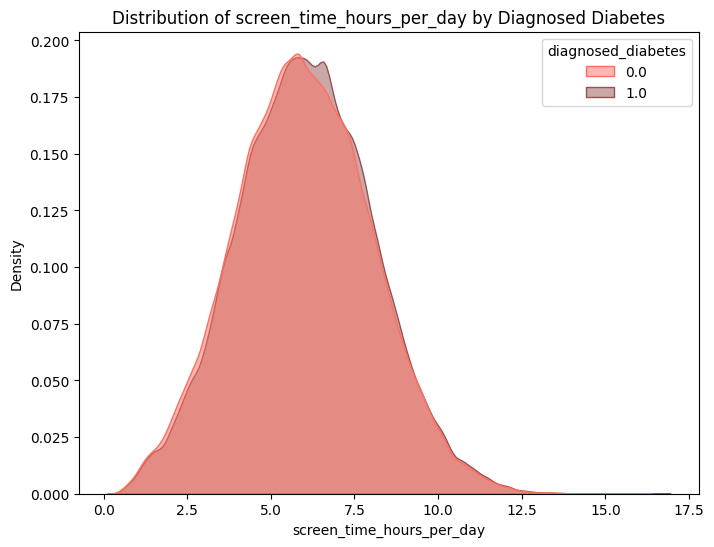

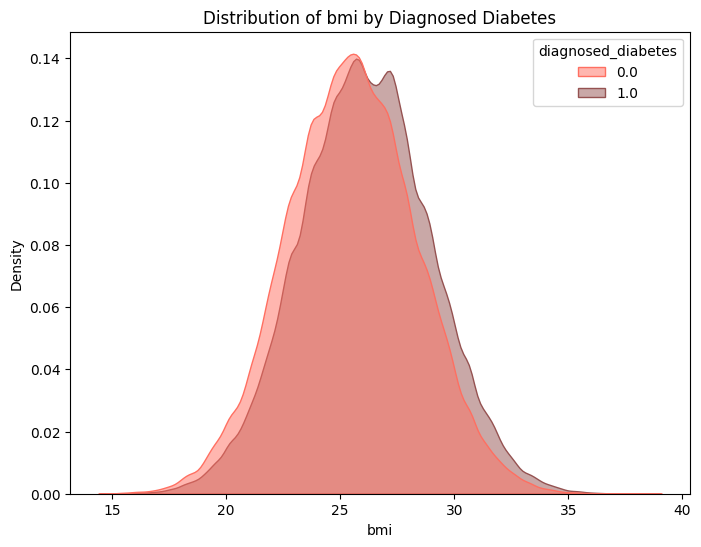

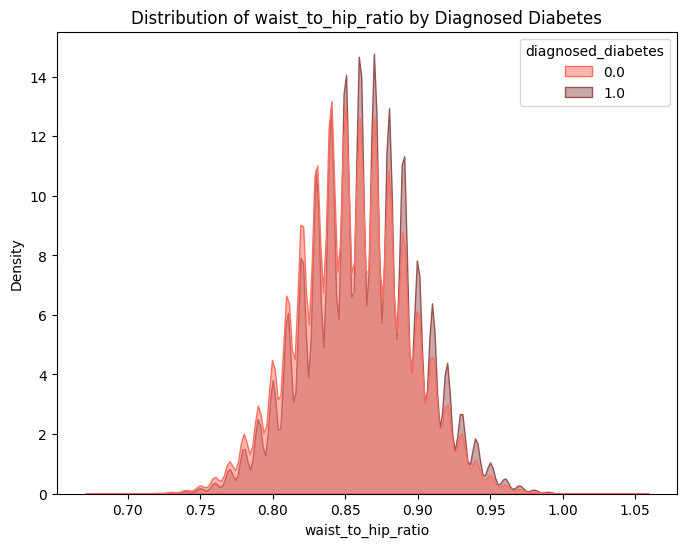

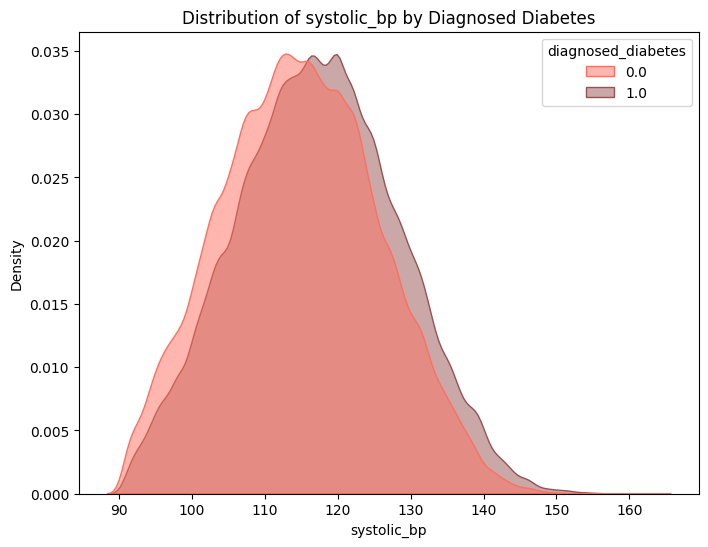

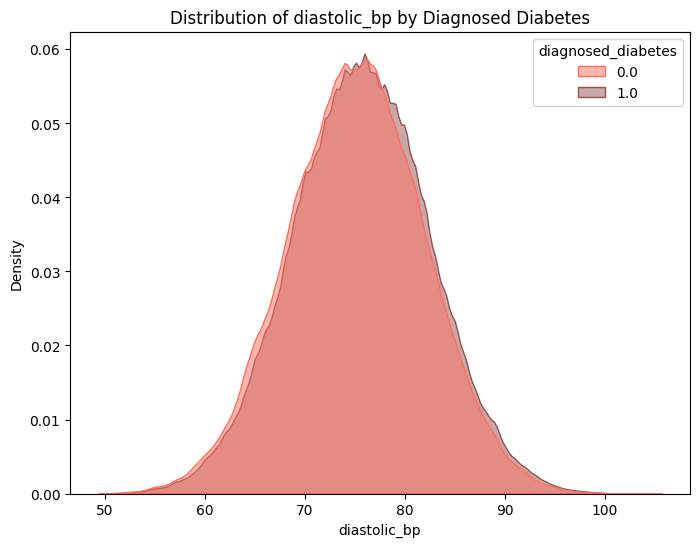

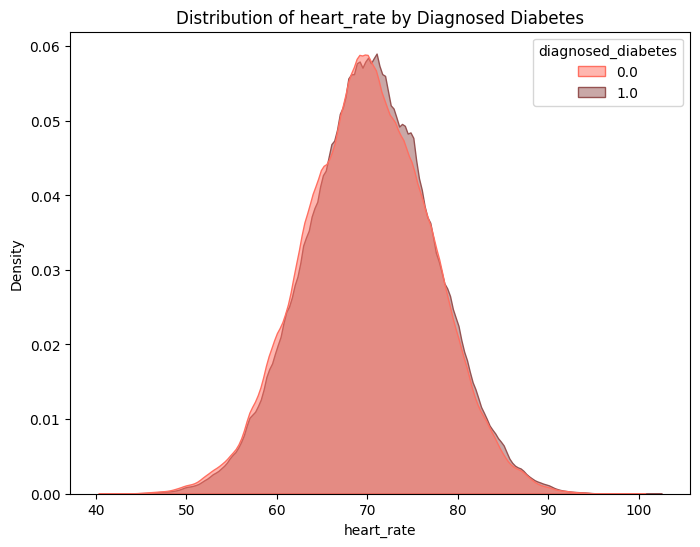

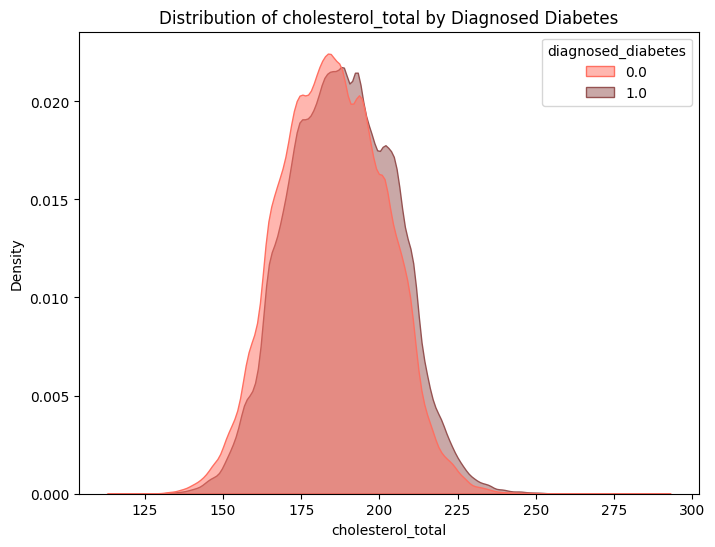

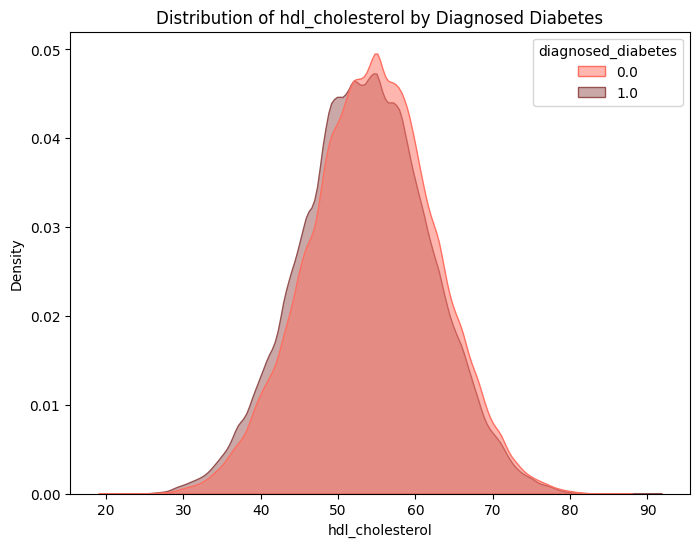

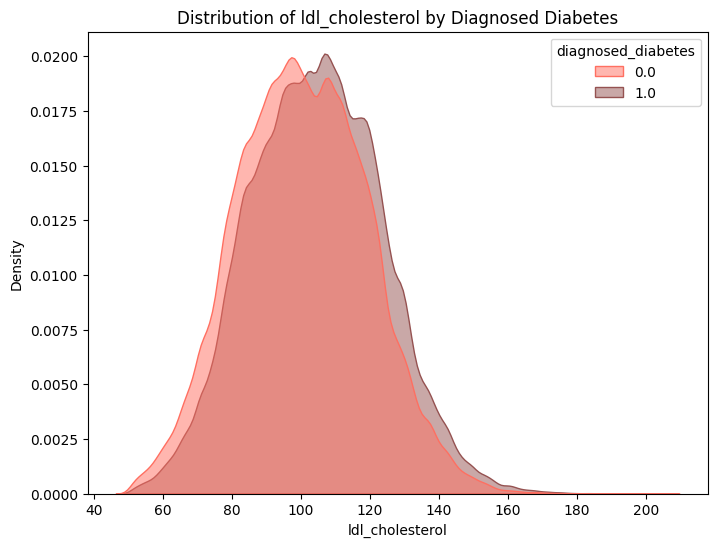

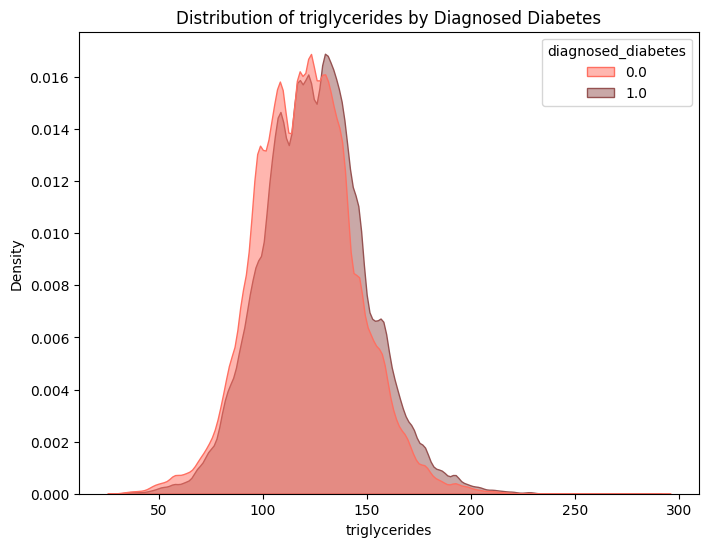

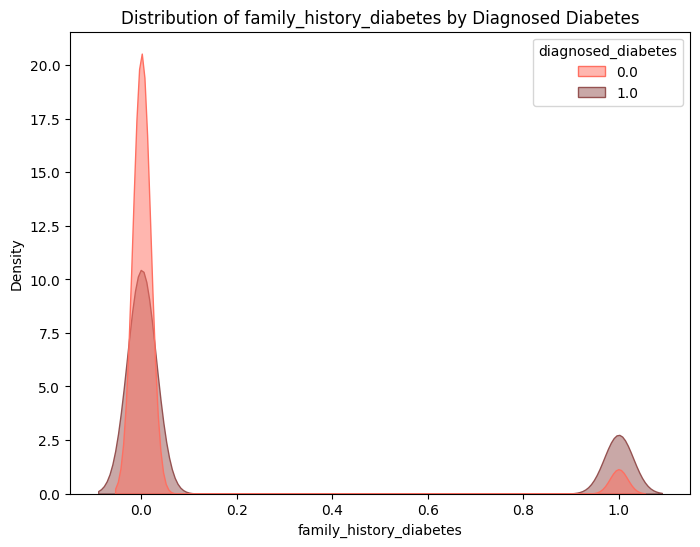

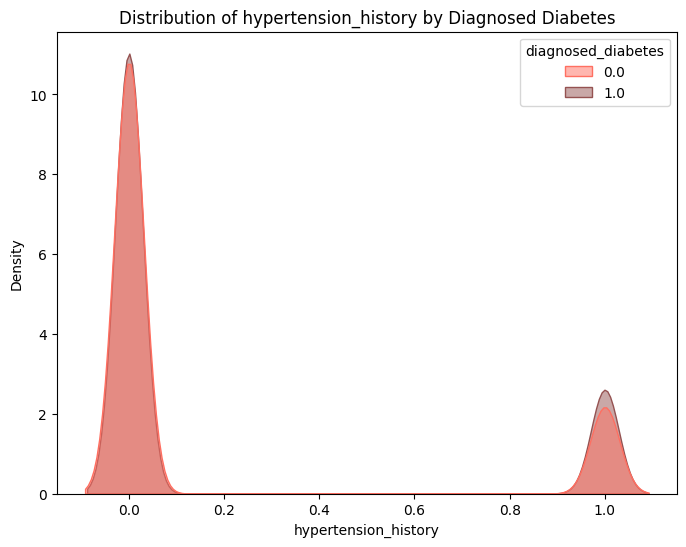

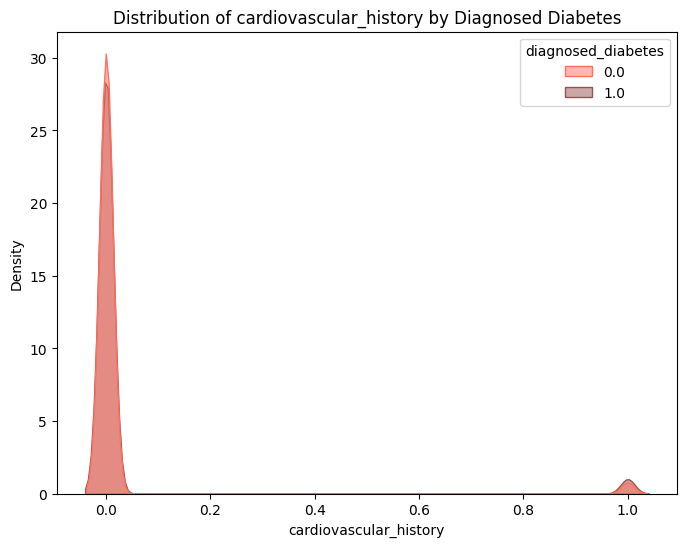

In [7]:
import seaborn as sns

for col in NUMS:
    try:
        plt.figure(figsize=(8,6))
        sns.kdeplot(data=train, x=col, hue='diagnosed_diabetes', fill=True, common_norm=False, alpha=0.5, palette={0: '#FF6F61', 1: '#955251'}) # KDE plot for numerical columns by target variable 
        plt.title(f'Distribution of {col} by Diagnosed Diabetes')
        plt.xlabel(col)
        plt.ylabel('Density')
        plt.show()
    except Exception:
        pass

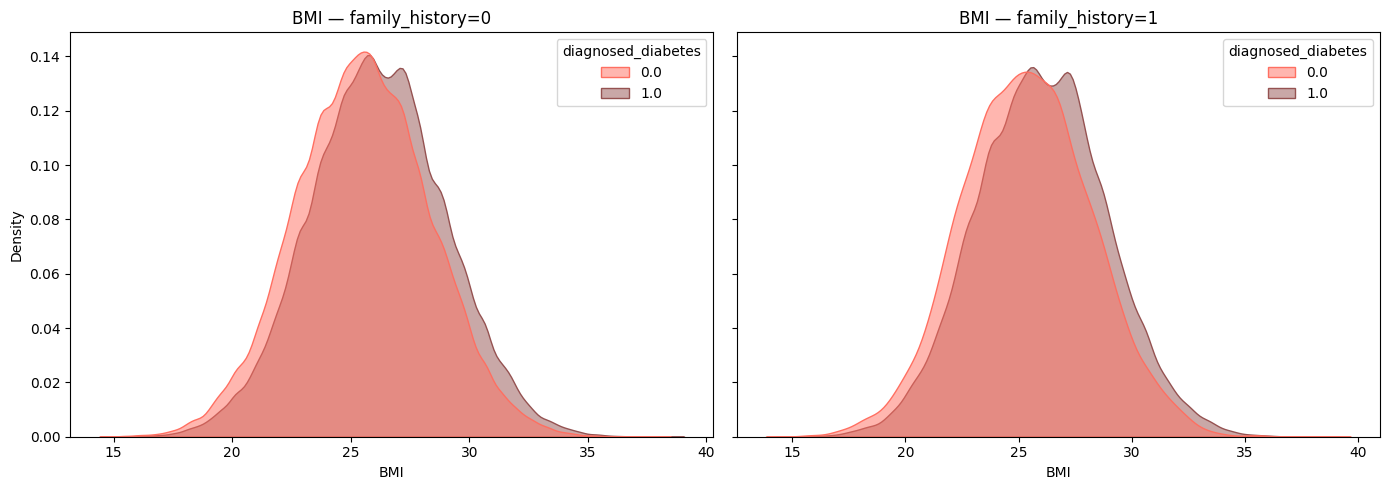

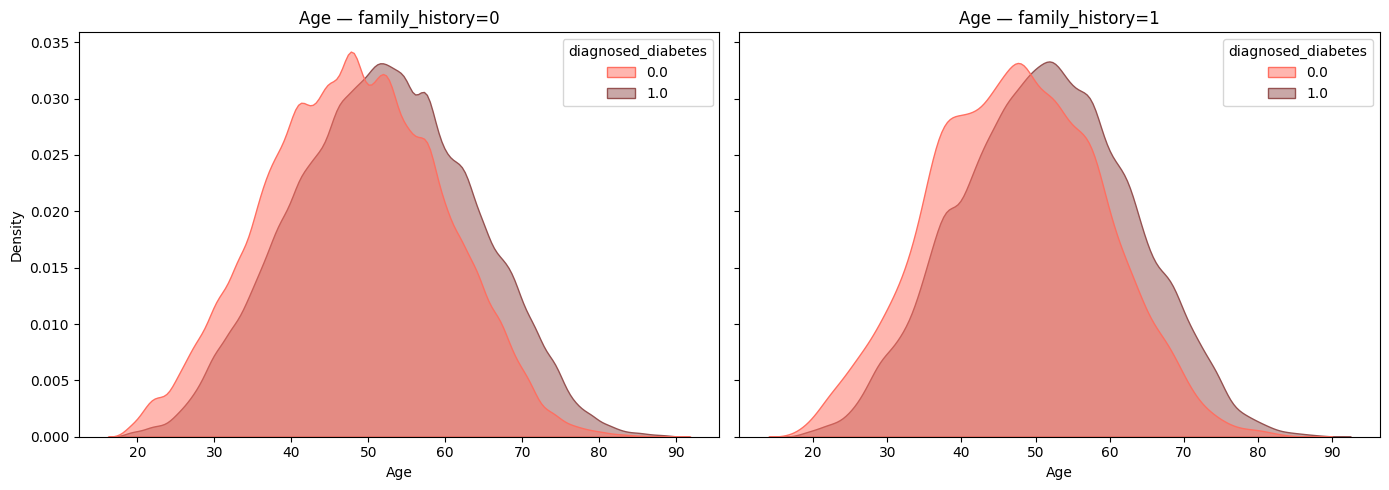

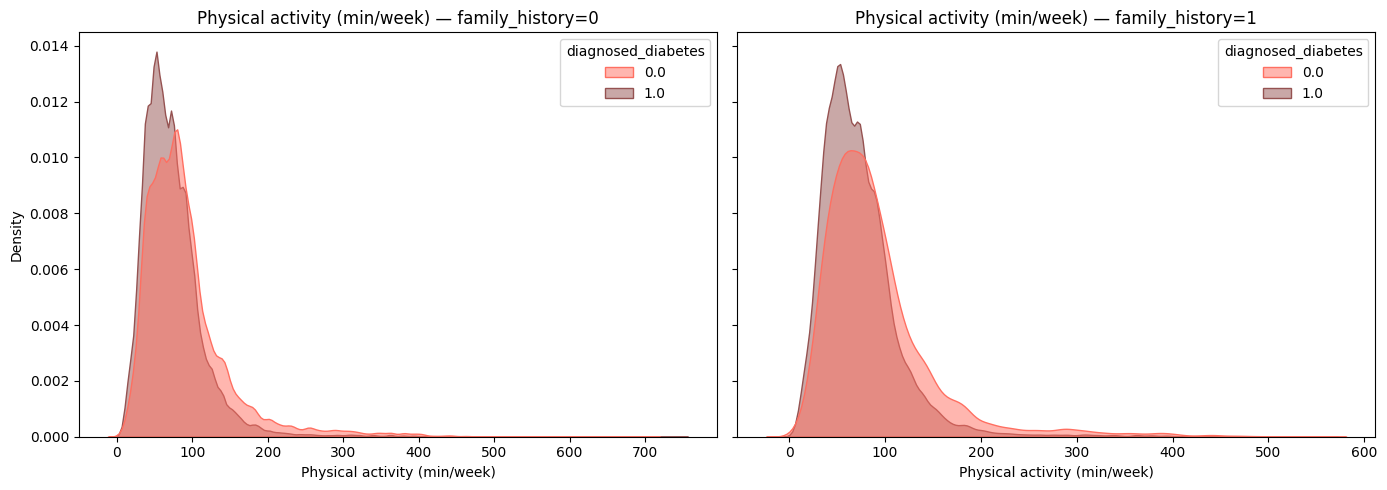

In [8]:
# KDE plots split by family_history_diabetes (two panels: family_history=0 and =1)
import seaborn as sns
import matplotlib.pyplot as plt

def plot_kde_by_family_history(var, label=None, bins=None):
    fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)
    for ax, fh in zip(axes, [0, 1]):
        df = train[train['family_history_diabetes'] == fh]
        sns.kdeplot(data=df, x=var, hue='diagnosed_diabetes', fill=True, common_norm=False, alpha=0.5, palette={0: '#FF6F61', 1: '#955251'}, ax=ax)
        ax.set_title(f"{label or var} — family_history={fh}")
        ax.set_xlabel(label or var)
    plt.tight_layout()
    plt.show()

# 1) BMI
plot_kde_by_family_history('bmi', label='BMI')

# 2) Age
plot_kde_by_family_history('age', label='Age')

# 3) Physical activity minutes per week
plot_kde_by_family_history('physical_activity_minutes_per_week', label='Physical activity (min/week)')


In [ ]:
train.groupby("smoking_status")[TARGET].mean() # Mean diagnosed_diabetes rate by smoking_status


smoking_status
Current    0.623124
Former     0.625331
Never      0.622911
Name: diagnosed_diabetes, dtype: float64

In [15]:
train['triglycerides_to_hdl_ratio'] = train['triglycerides'] / train['hdl_cholesterol']
NUMS.append('triglycerides_to_hdl_ratio')
train['total_cholesterol_to_hdl_ratio'] = train['cholesterol_total'] / train['hdl_cholesterol']
NUMS.append('total_cholesterol_to_hdl_ratio')

<Axes: >

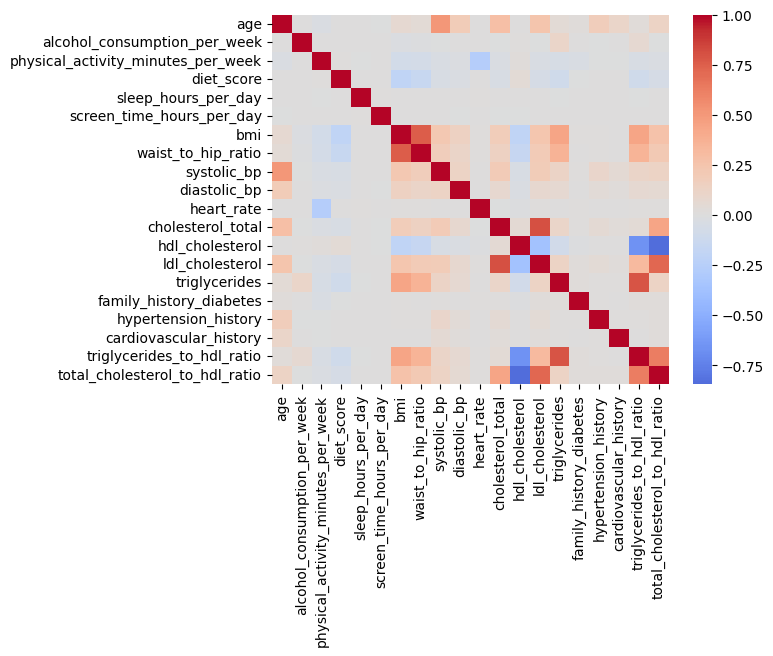

In [16]:
sns.heatmap(train[NUMS].corr(), cmap='coolwarm', center=0)
